# Aggregating impact projections to administrative units

This notebook takes climate impact projections at impact region level
and aggregates them to Colombia's administrative units. It uses a
sample of real Monte Carlo mortality projections: one batch, all 33
climate models, rcp85, SSP3. The full output has fifteen batches, so
treat the numbers here as a demonstration, not results.

You need the `cil_regionalization` package with the `[netcdf]` extra,
`matplotlib` for the plots, and a network connection. The weights come
from the published Zenodo records. The projection sample is committed
next to this notebook. Run it from this directory.

In [1]:
from pathlib import Path

import pandas as pd

import cil_regionalization as cilreg

DATA = Path("data")
DATA_VERSION = "world-combo-201710"  # the impact region version of the sample
BATCH = DATA / "montecarlo" / "batch0" / "rcp85"
GCMS = sorted(p.name for p in BATCH.iterdir() if p.is_dir())
print(len(GCMS), "climate models")


def damages_leaf(gcm):
    return BATCH / gcm / "low" / "SSP3" / "mortality_damages_IR_batch.nc4"

33 climate models


## Fetch the weights

`fetch_weights` downloads a weight file from Zenodo, checks it against
the checksum recorded when it was built, and caches it. Monetized
damages are dollar totals, so they need the `per_source` weights: each
region's total gets split between the departments it touches.

In [2]:
weights = cilreg.fetch_weights("gadm20-adm1-per-source")
print(len(weights.frame), "rows,", weights.normalization, ",", weights.source_version)

25236 rows, per_source , world-combo-201710


## Aggregate one draw

Start with a single draw: one climate model, one year. The weight file
covers the whole world, but this sample only has Colombia.
`restrict_to_sources` tells `apply_weights` which impact regions are
included. The department totals have to add back up to the region
totals, and `apply_weights` checks that; the two sums printed below
are the same number.

In [3]:
damages = cilreg.read_netcdf_leaf(
    damages_leaf("GFDL-ESM2G"),
    variables=["total_damages"], region_dim="region", region_col="hierid",
    kind="extensive",
)
col_regions = {(h,) for h in damages["hierid"].unique()}

adm1 = cilreg.apply_weights(
    weights, damages,
    kind="extensive", weight="pop", value_col="total_damages",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

d99 = adm1[adm1["year"] == 2099]
print(f"departments: {d99['ID_1'].nunique()}")
print(f"sum over departments:    {d99['total_damages'].sum():.6e}")
print(f"sum over impact regions: {damages.query('year == 2099')['total_damages'].sum():.6e}")

departments: 32
sum over departments:    -1.774214e+11
sum over impact regions: -1.774214e+11


## Map one draw

The geometry file `data/col_adm1_plot.parquet` is only used to make
the maps. It is the impact region shapes (Climate Impact Lab geometry,
published on Zenodo) merged into departments and simplified.

Negative values mean fewer deaths: under this cool climate model,
warming avoids more cold deaths than it adds heat deaths.

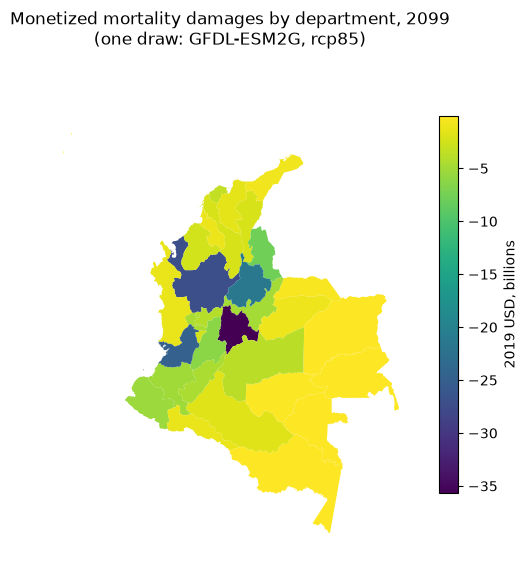

In [4]:
import geopandas as gpd

shapes = gpd.read_parquet(DATA / "col_adm1_plot.parquet")
m = shapes.merge(d99, on=["ISO", "ID_1"])
m["billions"] = m["total_damages"] / 1e9
ax = m.plot(column="billions", legend=True, cmap="viridis", figsize=(6, 7),
            legend_kwds={"label": "2019 USD, billions", "shrink": 0.7})
ax.set_title("Monetized mortality damages by department, 2099\n(one draw: GFDL-ESM2G, rcp85)")
ax.set_axis_off()

## Percent of GDP

Dollar totals mostly track population: big departments dominate. To
compare departments, divide by GDP. That is the third variable kind,
`ratio`: the damages and the GDP are each aggregated as totals, and
the division happens after, per department. Dividing first and
averaging the ratios would give a different, wrong answer.

The GDP comes embedded in the same projection files as the damages, so
both sides of the ratio use the same socioeconomic version. This is
also the form the published Climate Impact Lab tables use.

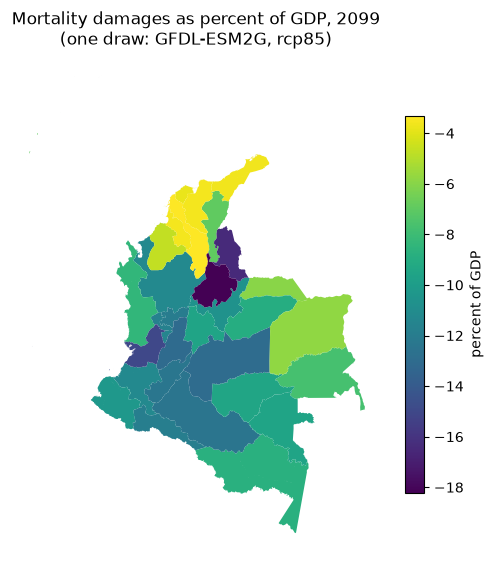

In [5]:
both = cilreg.read_netcdf_leaf(
    damages_leaf("GFDL-ESM2G"),
    variables=["total_damages", "gdp"], region_dim="region", region_col="hierid",
)

pct = cilreg.apply_weights(
    weights, both,
    kind="ratio", weight="pop",
    value_col="total_damages", denominator_col="gdp",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

p99 = pct[pct["year"] == 2099].copy()
p99["pct_gdp"] = p99["total_damages"] * 100

mp = shapes.merge(p99, on=["ISO", "ID_1"])
ax = mp.plot(column="pct_gdp", legend=True, cmap="viridis", figsize=(6, 7),
             legend_kwds={"label": "percent of GDP", "shrink": 0.7})
ax.set_title("Mortality damages as percent of GDP, 2099\n(one draw: GFDL-ESM2G, rcp85)")
ax.set_axis_off()

## Calculate statistics across draws

Each draw is aggregated first. The statistics are then calculated
across the aggregated draws. This order matters: summing per-region
quantiles would treat every region as having its worst draw at the
same time, which overstates the tails.

Here the 33 climate models are the draws. Each one is aggregated to
departments, averaged over 2080 to 2099, and then pooled.

In [6]:
frames = []
for gcm in GCMS:
    data = cilreg.read_netcdf_leaf(damages_leaf(gcm), variables=["total_damages"],
                                   region_dim="region", region_col="hierid",
                                   kind="extensive")
    applied = cilreg.apply_weights(
        weights, data, kind="extensive", weight="pop",
        value_col="total_damages", data_version=DATA_VERSION,
        restrict_to_sources=col_regions,
    )
    frames.append(applied.frame.assign(gcm=gcm))
draws = pd.concat(frames, ignore_index=True)

stats = cilreg.summarize_samples(
    draws,
    sample_dims=["gcm"], time_col="year", window=(2080, 2099),
    value_col="total_damages", quantiles=[0.05, 0.5, 0.95],
)
stats[stats["ID_1"] == 1]

,ISO,ID_1,statistic,total_damages
0,COL,1,mean,7.524689e+08
32,COL,1,q05,-2.574818e+08
64,COL,1,q50,1.070259e+08
96,COL,1,q95,2.382266e+09


## One draw against a pooled quantile

The left map is the single draw from above. The right map is the 95th
percentile across all 33 models, of the 2080 to 2099 average. One
model gives one arbitrary picture; the quantile says something about
the range of pictures.

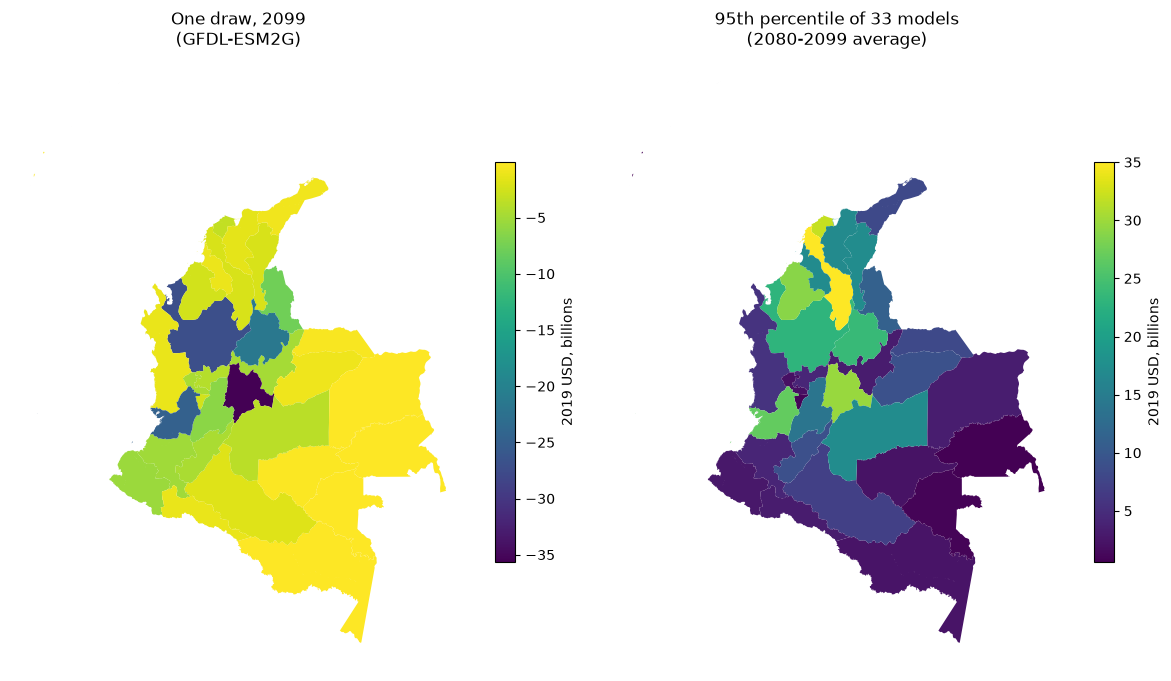

In [7]:
import matplotlib.pyplot as plt

q95 = stats[stats["statistic"] == "q95"].copy()
q95["billions"] = q95["total_damages"] / 1e9

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
m.plot(column="billions", legend=True, cmap="viridis", ax=axes[0],
       legend_kwds={"label": "2019 USD, billions", "shrink": 0.6})
axes[0].set_title("One draw, 2099\n(GFDL-ESM2G)")
shapes.merge(q95, on=["ISO", "ID_1"]).plot(
    column="billions", legend=True, cmap="viridis", ax=axes[1],
    legend_kwds={"label": "2019 USD, billions", "shrink": 0.6})
axes[1].set_title("95th percentile of 33 models\n(2080-2099 average)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()

## The spread behind the quantiles

Each dot is one climate model's 2080 to 2099 average for one
department. This spread is what the quantiles summarize, and it is why
each draw has to be aggregated before the statistics: the quantiles
are taken across these dots.

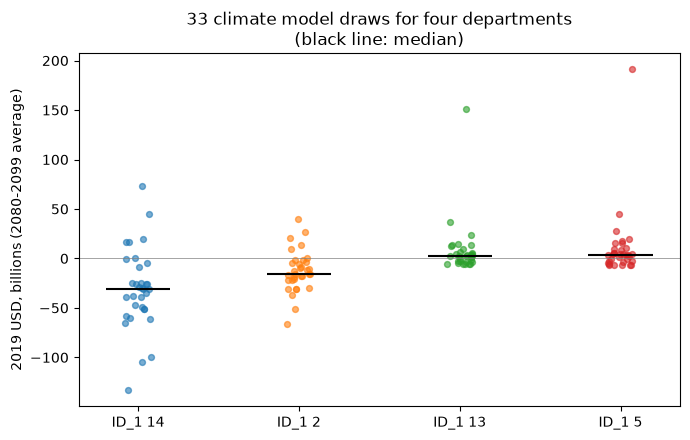

In [8]:
import numpy as np

wmeans = (draws[draws["year"].between(2080, 2099)]
          .groupby(["ID_1", "gcm"])["total_damages"].mean().reset_index())
med = wmeans.groupby("ID_1")["total_damages"].median()
picked = list(med.sort_values().index[:2]) + list(med.sort_values().index[-2:])

fig, ax = plt.subplots(figsize=(7, 4.5))
rng = np.random.default_rng(0)
for i, dep in enumerate(picked):
    vals = wmeans[wmeans["ID_1"] == dep]["total_damages"] / 1e9
    ax.scatter(i + rng.uniform(-0.08, 0.08, len(vals)), vals,
               alpha=0.6, s=18)
    ax.hlines(vals.median(), i - 0.2, i + 0.2, color="black")
ax.set_xticks(range(len(picked)), [f"ID_1 {d}" for d in picked])
ax.set_ylabel("2019 USD, billions (2080-2099 average)")
ax.set_title("33 climate model draws for four departments\n(black line: median)")
ax.axhline(0, color="gray", lw=0.5)
plt.tight_layout()

## Other levels

The same operation works at any level; only the weight file changes.

At country level, Colombia is a single unit, so the total is just the
sum over departments. An ADM0 weight file would do the same thing with
coarser weights.

In [9]:
print(f"Colombia total, 2099, one draw: {d99['total_damages'].sum() / 1e9:.1f} billion 2019 USD")

Colombia total, 2099, one draw: -177.4 billion 2019 USD


At municipality level (ADM2), the finer weight file does more work: in
this geometry version a Colombian impact region is a group of
municipalities, and one region's total can spread across as many as 90
of them by population share. The totals still add back up.

In [10]:
weights_adm2 = cilreg.fetch_weights("gadm20-adm2-per-source")

adm2 = cilreg.apply_weights(
    weights_adm2, damages,
    kind="extensive", weight="pop", value_col="total_damages",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

a99 = adm2[adm2["year"] == 2099]
print(f"municipalities: {len(a99)}")
print(f"sum over municipalities: {a99['total_damages'].sum():.6e}")
print(f"sum over departments:    {d99['total_damages'].sum():.6e}")

municipalities: 1065
sum over municipalities: -1.774214e+11
sum over departments:    -1.774214e+11


## Other variable types

Rates, like deaths per person per year, are averages rather than
totals. They use the `per_destination` weights, which average over the
regions inside each unit. The script next to this notebook,
`run_example.py`, runs the rates at ADM1 and ADM2 from the command
line, and has an `--offline` mode that uses committed weight slices
instead of fetching. Its sample for rates is different (two batches of
one model), because the tree holding the rates is still being
regenerated. The README in this directory shows the script's full
output.